<center>
September 30, 2026  

![Logo ITQ](img/LogoITQ.png)

**01 PAO26-26 Python 1, EXAMEN FINAL**  

![Logo Python](img/LogoPython.png)

</center>

**Docente:** Elvis Pachacama  

**Estudiante:** Dilan Salazar, Ronny Bastidas

**Repositorio Dilan Salazar:** [Machine Learning 2026](https://github.com/Dashmp/MachineLearning2.git)

## Objetivo

Desarrollar un proceso completo de Machine Learning para construir un modelo de regresión lineal múltiple capaz de estimar los gastos médicos (`charges`) a partir de las características disponibles en el conjunto de datos, aplicando análisis exploratorio, tratamiento de datos, detección de valores atípicos, transformación de variables, selección de atributos, validación, entrenamiento, evaluación y predicción de nuevas observaciones.

## Descripción de la actividad

Una organización relacionada con servicios de salud desea analizar qué características de sus registros están asociadas con los costos médicos y construir un modelo que permita estimar el valor de (`charges`) para nuevas observaciones.
El dataset proporciona edad, sexo, índice de masa corporal (BMI), número de dependientes, condición de fumador, región y gastos médicos.
El estudiante deberá desarrollar un notebook que resuelva las siguientes etapas.
El conjunto de dato se desde kaggle debe ser automatizado la descarga desde el mismo lenguaje

## Desarollo

1. Carga y comprensión de los datos.
2. EDA y calidad de los datos.
3. Detección de valores atípicos.
4. Preparación de variables.
5. Normalización o estandarización.
6. Selección de atributos.
7. Validación de datos.
8. Entrenamiento mediante Regresión Lineal.
9. Evaluación.
10. Predicción con nuevos datos.

## Recursos necesarios

- Dataset `insurance.csv` de Kaggle.
- Anaconda / JupyterLab.
- Generar el pipelin detallada de cada una de las fases dlproyecto 

## Configuración e instalación de librerías

In [1]:
# Manipulación de datos
import glob
import warnings
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Configuración visual
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
# Importamos la api.key, para que cargar los datos 
import os
os.environ["KAGGLE_CONFIG_DIR"]="C:/Users/ESTUDIANTE/.kaggle"

## 1.	Carga y comprensión de los datos — 10 %

In [3]:
# Revisamos la ruta del archivo para importarlo
import os

print(os.path.abspath("insurance.csv"))


C:\Users\USUARIO\Machine2026\Machine2\insurance.csv


In [4]:
# Cargar el dataset y 
df = pd.read_csv("insurance.csv")

print("Dimensiones del dataset:", df.shape)

display(df.head())


Dimensiones del dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Información general del dataset
print("Información general:")
df.info()

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
# Estadísticas descriptivas de las variables numéricas
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [7]:
# Estadísticas descriptivas incluyendo variables categóricas
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [8]:
# Cantidad de valores nulos por columna
print("Valores nulos por columna:")
display(df.isnull().sum().to_frame("nulos"))

# Cantidad de registros duplicados
print("Cantidad de registros duplicados:", df.duplicated().sum())


Valores nulos por columna:


,nulos
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Cantidad de registros duplicados: 1


## 2.	EDA y calidad de los datos — 15 %

In [9]:
# Valores únicos de las variables categóricas
categorical_columns = ["sex", "smoker", "region"]

for column in categorical_columns:
    print(f"\nValores de {column}:")
    print(df[column].value_counts())


Valores de sex:
sex
male      676
female    662
Name: count, dtype: int64

Valores de smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

Valores de region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


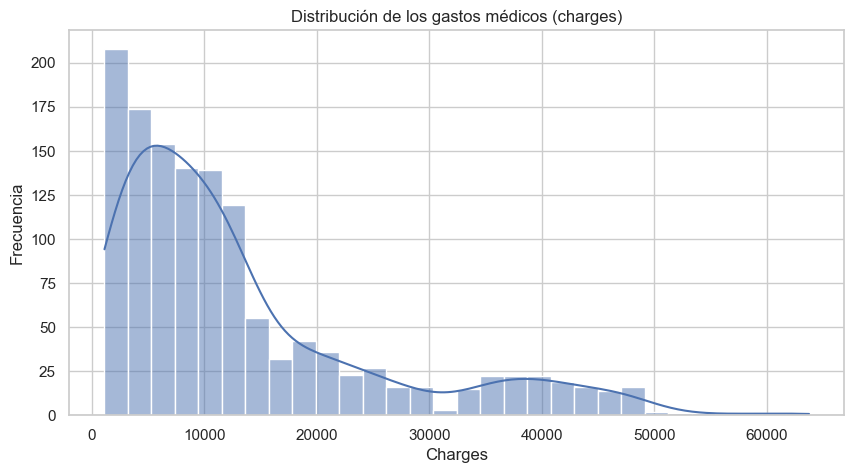

In [10]:
# Distribución de la variable objetivo
plt.figure(figsize=(10, 5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribución de los gastos médicos (charges)")
plt.xlabel("Charges")
plt.ylabel("Frecuencia")
plt.show()


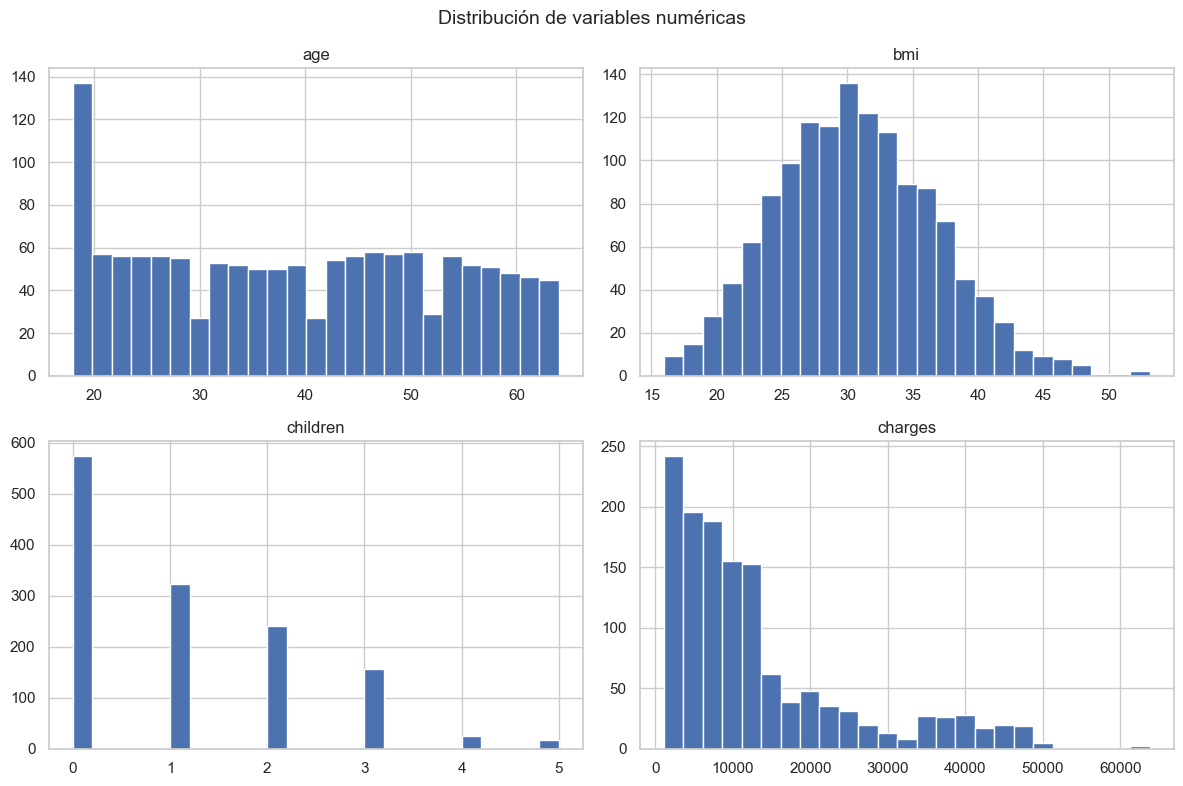

In [11]:
# Distribución de las variables numéricas
numeric_columns = ["age", "bmi", "children", "charges"]

df[numeric_columns].hist(figsize=(12, 8), bins=25)
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()


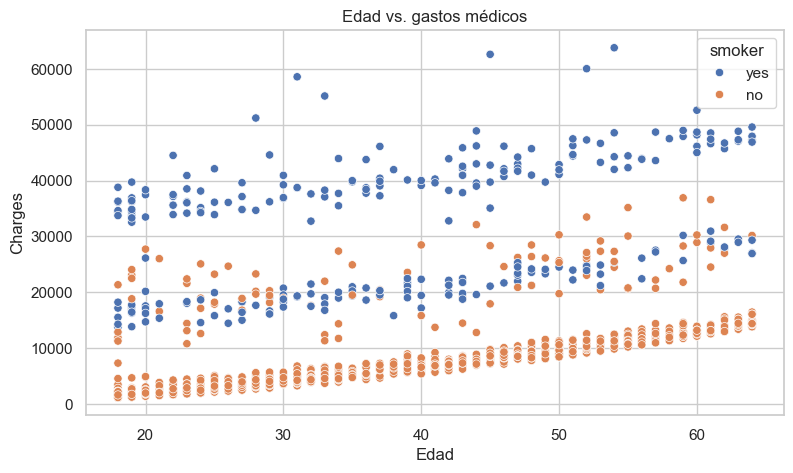

In [12]:
# Relación entre edad y gastos médicos
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Edad vs. gastos médicos")
plt.xlabel("Edad")
plt.ylabel("Charges")
plt.show()


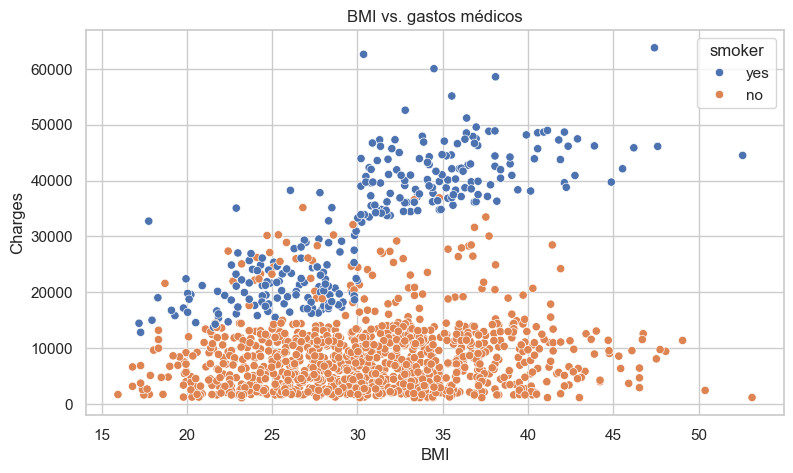

In [13]:
# Relación entre BMI y gastos médicos
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs. gastos médicos")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()


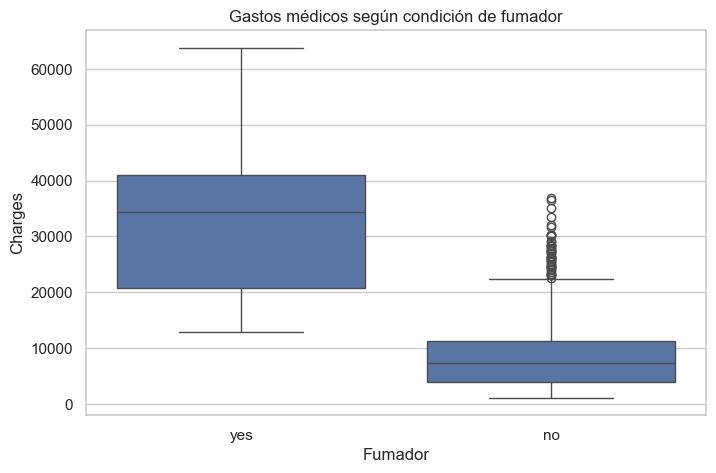

In [14]:
# Comparación de gastos médicos según condición de fumador
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Gastos médicos según condición de fumador")
plt.xlabel("Fumador")
plt.ylabel("Charges")
plt.show()

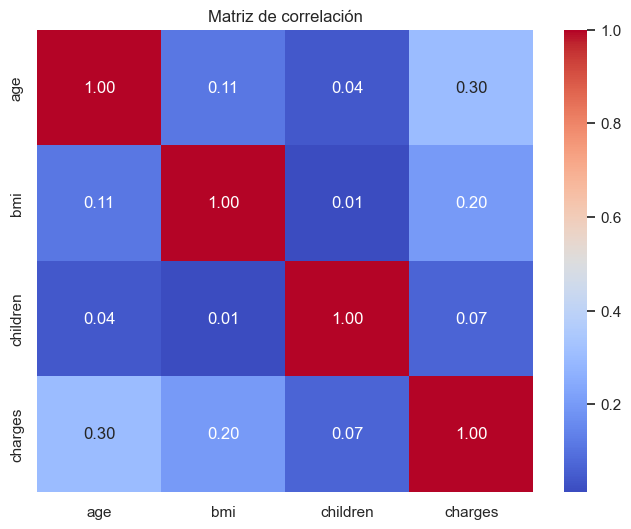

In [15]:
# Matriz de correlación de variables numéricas
correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()


### Análisis del EDA

El análisis exploratorio permite observar que `charges` presenta una distribución asimétrica y que existen diferencias importantes en los gastos médicos entre personas fumadoras y no fumadoras. También se observa relación entre algunas variables numéricas y los gastos.

Las variables categóricas no pueden introducirse directamente en una regresión lineal; por ello posteriormente serán transformadas mediante **One-Hot Encoding**.

## 3. Detección de outliers — 10 %

In [16]:
# Función para detectar outliers mediante IQR
def detectar_outliers_iqr(data, columns):
    resultados = []

    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        mascara = (data[column] < limite_inferior) | (data[column] > limite_superior)

        resultados.append({
            "variable": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "cantidad_outliers": int(mascara.sum()),
            "porcentaje_outliers": round(mascara.mean() * 100, 2)
        })

    return pd.DataFrame(resultados)

outlier_summary = detectar_outliers_iqr(df, ["age", "bmi", "children", "charges"])
display(outlier_summary)

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
0,age,27.00000,51.000000,24.000000,-9.000000,87.000000,0,0.00
1,bmi,26.29625,34.693750,8.397500,13.700000,47.290000,9,0.67
2,children,0.00000,2.000000,2.000000,-3.000000,5.000000,0,0.00
3,charges,4740.28715,16639.912515,11899.625365,-13109.150897,34489.350562,139,10.39


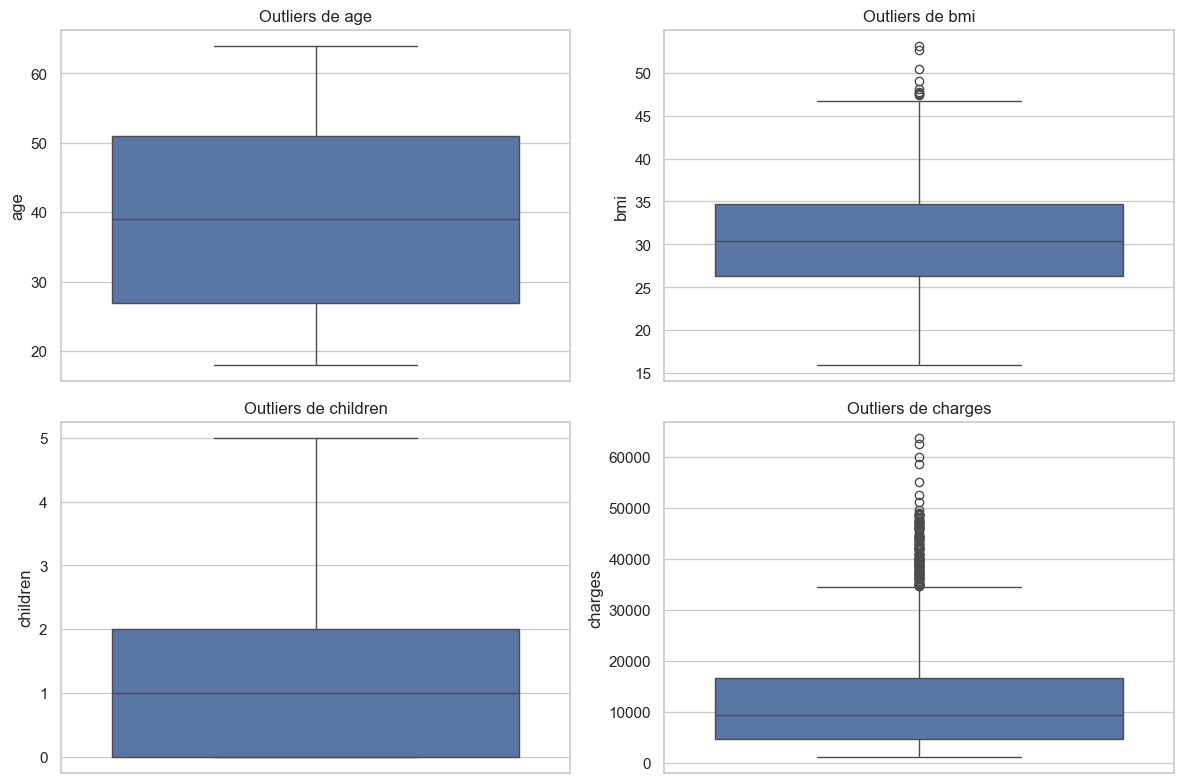

In [17]:
# Visualización de posibles valores atípicos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.ravel(), ["age", "bmi", "children", "charges"]):
    sns.boxplot(y=df[column], ax=ax)
    ax.set_title(f"Outliers de {column}")

plt.tight_layout()
plt.show()


## 4. Preparación de variables — 10 %

In [18]:
# Eliminar duplicados si existen
df_model = df.drop_duplicates().copy()

# Variable objetivo
X = df_model.drop(columns=["charges"])
y = df_model["charges"]

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

print("Variables predictoras:", list(X.columns))
print("Variable objetivo: charges")
print("Registros utilizados:", len(df_model))


Variables predictoras: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Variable objetivo: charges
Registros utilizados: 1337


In [19]:
# Separación en entrenamiento y prueba.
# El conjunto de prueba representa el 20% de los datos.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1069, 6)
Datos de prueba: (268, 6)


## 5. Normalización o estandarización — 10 %

In [20]:
# Transformador para variables numéricas:
# estandarización con media 0 y desviación estándar 1.
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Transformador para variables categóricas:
# convierte categorías en columnas binarias.
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

# Preprocesador general
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocesador configurado correctamente.")

Preprocesador configurado correctamente.


## 6. Selección de atributos — 10 %

In [21]:
# Pipeline completo:
# 1. Preprocesamiento
# 2. Selección de atributos
# 3. Regresión lineal

modelo = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("selector", SelectKBest(score_func=f_regression, k=8)),
        ("regressor", LinearRegression())
    ]
)

print("Pipeline creado:")
display(modelo)

Pipeline creado:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0

## 7. Validación de datos — 10 %

In [22]:
# Validación cruzada de 5 particiones sobre entrenamiento
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(
    modelo,
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)

print("R² de cada partición:")
print(np.round(cv_r2, 4))

print("\nR² promedio:", round(cv_r2.mean(), 4))
print("Desviación estándar:", round(cv_r2.std(), 4))


R² de cada partición:
[0.729  0.7151 0.7729 0.6884 0.7085]

R² promedio: 0.7228
Desviación estándar: 0.0283


## 8. Entrenamiento mediante Regresión Lineal — 10 %

In [23]:
# Entrenar el pipeline utilizando únicamente los datos de entrenamiento
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


In [24]:
# Mostrar los atributos seleccionados por SelectKBest

# Obtener nombres de atributos después del One-Hot Encoding
feature_names = modelo.named_steps["preprocessor"].get_feature_names_out()

# Obtener máscara de selección
selector = modelo.named_steps["selector"]
selected_mask = selector.get_support()

selected_features = feature_names[selected_mask]

print("Atributos seleccionados:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

Atributos seleccionados:
1. num__age
2. num__bmi
3. num__children
4. cat__sex_male
5. cat__smoker_yes
6. cat__region_northwest
7. cat__region_southeast
8. cat__region_southwest


In [25]:
# Coeficientes de la regresión lineal
regressor = modelo.named_steps["regressor"]

coeficientes = pd.DataFrame({
    "atributo": selected_features,
    "coeficiente": regressor.coef_
}).sort_values("coeficiente", key=abs, ascending=False)

display(coeficientes)

print("Intercepto:", regressor.intercept_)

,atributo,coeficiente
4,cat__smoker_yes,23077.764593
0,num__age,3472.975553
1,num__bmi,1927.828251
6,cat__region_southeast,-838.919616
7,cat__region_southwest,-659.139752
2,num__children,636.501185
5,cat__region_northwest,-391.761455
3,cat__sex_male,-101.542054


Intercepto: 8947.952195069174


## 9. Evaluación del modelo — 10 %

In [26]:
# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metricas = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Valor": [mae, rmse, r2]
})

display(metricas)

,Métrica,Valor
0,MAE,4177.045561
1,RMSE,5956.342894
2,R²,0.806929


In [27]:
# Tabla de valores reales y predichos
resultados = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred,
    "Error": y_test.values - y_pred
})

display(resultados.head(15))


,Real,Predicción,Error
0,8688.85885,8143.693884,545.164966
1,5708.86700,5737.115683,-28.248683
2,11436.73815,14369.314876,-2932.576726
3,38746.35510,31745.513636,7000.841464
4,4463.20510,8962.386657,-4499.181557
5,9304.70190,13149.722353,-3845.020453
6,38511.62830,30446.760679,8064.867621
7,2150.46900,1453.288813,697.180187
8,7345.72660,10633.018402,-3287.291802
9,10264.44210,11318.943794,-1054.501694


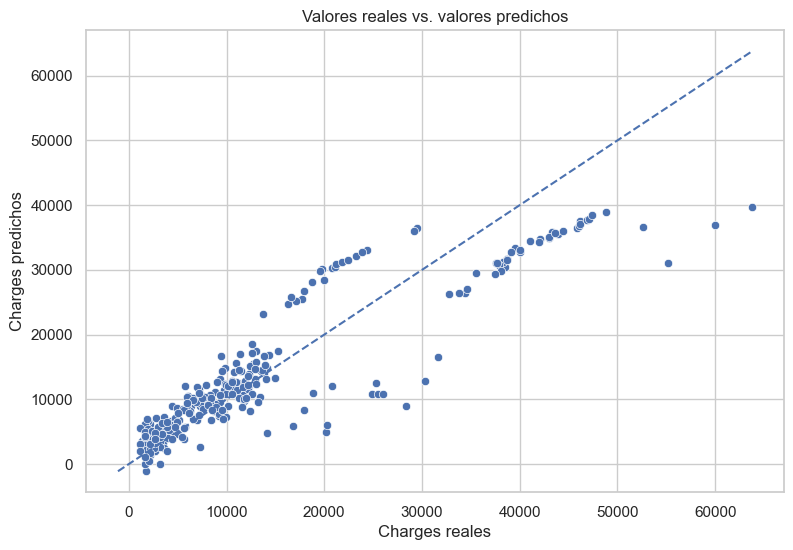

In [28]:
# Gráfico de valores reales vs. predichos
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

# Línea ideal: predicción = valor real
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Valores reales vs. valores predichos")
plt.xlabel("Charges reales")
plt.ylabel("Charges predichos")
plt.show()

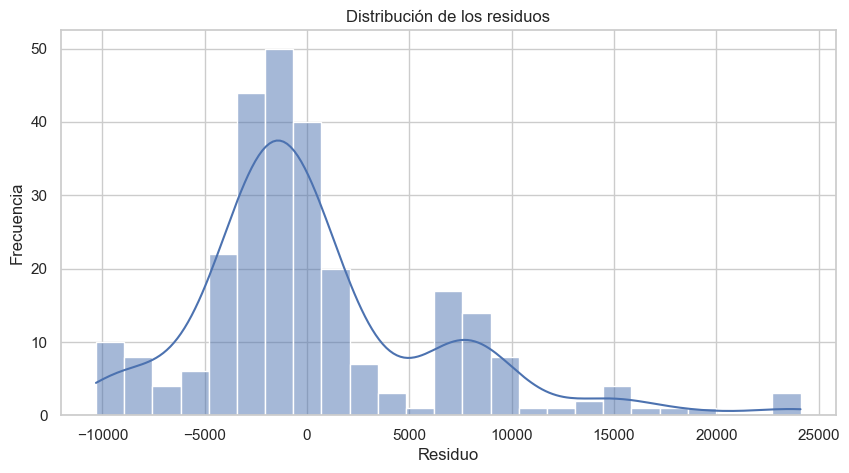

In [29]:
# Distribución de los errores/residuos
residuos = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True)
plt.title("Distribución de los residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()


## 10. Predicción con nuevos datos — 5 %

In [30]:
# Crear una nueva observación.
# Modifique estos valores para realizar otras predicciones.

nuevo_paciente = pd.DataFrame({
    "age": [35],
    "sex": ["male"],
    "bmi": [28.5],
    "children": [2],
    "smoker": ["no"],
    "region": ["southeast"]
})

display(nuevo_paciente)

prediccion = modelo.predict(nuevo_paciente)

print(f"Gasto médico estimado (charges): ${prediccion[0]:,.2f}")

,age,sex,bmi,children,smoker,region
0,35,male,28.5,2,no,southeast


Gasto médico estimado (charges): $6,803.27


In [31]:
# Ejemplo con varios pacientes nuevos

nuevos_pacientes = pd.DataFrame({
    "age": [25, 45, 60],
    "sex": ["female", "male", "female"],
    "bmi": [24.5, 31.2, 29.8],
    "children": [0, 2, 3],
    "smoker": ["no", "no", "yes"],
    "region": ["southwest", "northeast", "southeast"]
})

predicciones = modelo.predict(nuevos_pacientes)

resultado_nuevos = nuevos_pacientes.copy()
resultado_nuevos["charges_estimado"] = predicciones

display(resultado_nuevos)

,age,sex,bmi,children,smoker,region,charges_estimado
0,25,female,24.5,0,no,southwest,2261.661261
1,45,male,31.2,2,no,northeast,10984.792995
2,60,female,29.8,3,yes,southeast,37135.168801


# Pipeline detallado del proyecto

El proyecto implementa un pipeline de Machine Learning que integra las principales etapas de preparación y modelado en una única estructura.

El flujo general del proyecto es:

**Kaggle → Carga de datos → Comprensión → EDA → Calidad de datos → Detección de outliers → Separación de variables → División Train/Test → Preprocesamiento → Selección de atributos → Regresión Lineal → Validación → Evaluación → Predicción**

## Pipeline de Machine Learning

El pipeline técnico utilizado en el modelo está compuesto por tres etapas principales:

1. **Preprocesamiento de datos**
   - Las variables numéricas (`age`, `bmi` y `children`) se estandarizan mediante `StandardScaler`.
   - Las variables categóricas (`sex`, `smoker` y `region`) se convierten a variables numéricas mediante `OneHotEncoder`.

2. **Selección de atributos**
   - Se utiliza `SelectKBest` junto con `f_regression`.
   - Se seleccionan los 8 atributos con mayor relación estadística con la variable objetivo `charges`.

3. **Modelo de regresión**
   - Se utiliza `LinearRegression` para estimar los gastos médicos.

El pipeline permite ejecutar estas etapas de manera ordenada y evita realizar manualmente las transformaciones cada vez que se utilizan nuevos datos.

### Flujo técnico

```text
                  DATOS ORIGINALES
                         │
                         ▼
                División Train/Test
                         │
                         ▼
                ┌─────────────────┐
                │ Preprocesamiento│
                └────────┬────────┘
                         │
              ┌──────────┴──────────┐
              │                     │
              ▼                     ▼
       Variables numéricas   Variables categóricas
              │                     │
              ▼                     ▼
       StandardScaler        OneHotEncoder
              │                     │
              └──────────┬──────────┘
                         ▼
                 Datos transformados
                         │
                         ▼
                  SelectKBest
                 f_regression
                    k = 8
                         │
                         ▼
                Atributos seleccionados
                         │
                         ▼
                 LinearRegression
                         │
                         ▼
                    Predicción
                     charges


## Conclusión

La actividad permitió aplicar un proceso completo de Machine Learning para predecir los gastos médicos mediante un modelo de Regresión Lineal Múltiple. Se comprobó la importancia del análisis exploratorio, la preparación de variables, la detección de valores atípicos, la estandarización y la selección de atributos antes del entrenamiento. Además, el uso de un Pipeline permitió integrar estas etapas de forma ordenada y reproducible, facilitando la validación, evaluación y predicción de nuevos datos. En conclusión, el desarrollo permitió comprender cómo las técnicas de Machine Learning transforman datos reales en modelos capaces de generar predicciones útiles para la toma de decisiones.